# BOPTEST

TESTCASE=multizone_office_simple_air podman-compose up -d
podman-compose ps

podman-compose start test



podman-compose start mc
podman-compose start provision

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Your local Fedora Podman address
url = "http://localhost:8000"

# Select a testcase
# (You saw these names in your provision_1 logs earlier)
testcase = "multizone_office_simple_air"

# 1. Select the test case on the server
# This returns a 'testid' which is a unique session ID
select_res = requests.post(f"{url}/testcases/{testcase}/select").json()
testid = select_res['testid']
print(f"Selected Testcase: {testcase}")
print(f"Session TestID: {testid}")

# 2. Initialize the simulation
# start_time is in seconds from the beginning of the year
# warmup_period is the lead-up time for thermal stability
init_params = {
    'start_time': 0, 
    'warmup_period': 0
}
res = requests.put(f"{url}/initialize/{testid}", data=init_params).json()

print("Simulation Initialized!")

Selected Testcase: multizone_office_simple_air
Session TestID: 781a2851-5cc0-4188-a621-d4b629b5053a
Simulation Initialized!


In [10]:
# Unpack the 'payload'
all_inputs = requests.get(f"{url}/inputs/{testid}").json()['payload']
all_measurements = requests.get(f"{url}/measurements/{testid}").json()['payload']

print(f"{'KEY':<25} | {'UNIT':<10} | {'DESCRIPTION'}")
print("-" * 80)

print("--- INPUTS (ACTUATORS) ---")
for key in sorted(all_inputs.keys()):
    # Force values to strings and handle None
    u = all_inputs[key].get('Unit')
    unit = str(u) if u is not None else "N/A"
    
    d = all_inputs[key].get('description')
    desc = str(d) if d is not None else "No description"
    
    print(f"{key:<25} | {unit:<10} | {desc}")

print("\n--- MEASUREMENTS (SENSORS) ---")
for key in sorted(all_measurements.keys()):
    u = all_measurements[key].get('Unit')
    unit = str(u) if u is not None else "N/A"
    
    d = all_measurements[key].get('description')
    desc = str(d) if d is not None else "No description"
    
    print(f"{key:<25} | {unit:<10} | {desc}")

KEY                       | UNIT       | DESCRIPTION
--------------------------------------------------------------------------------
--- INPUTS (ACTUATORS) ---
hvac_oveAhu_TSupSet_activate | N/A        | No description
hvac_oveAhu_TSupSet_u     | K          | No description
hvac_oveAhu_dpSet_activate | N/A        | No description
hvac_oveAhu_dpSet_u       | Pa         | No description
hvac_oveAhu_yCoo_activate | N/A        | No description
hvac_oveAhu_yCoo_u        | 1          | No description
hvac_oveAhu_yFan_activate | N/A        | No description
hvac_oveAhu_yFan_u        | 1          | No description
hvac_oveAhu_yHea_activate | N/A        | No description
hvac_oveAhu_yHea_u        | 1          | No description
hvac_oveAhu_yOA_activate  | N/A        | No description
hvac_oveAhu_yOA_u         | 1          | No description
hvac_oveAhu_yPumCoo_activate | N/A        | No description
hvac_oveAhu_yPumCoo_u     | 1          | No description
hvac_oveAhu_yPumHea_activate | N/A        | No d

Starting experiment: Locking Sou damper at 40.0%


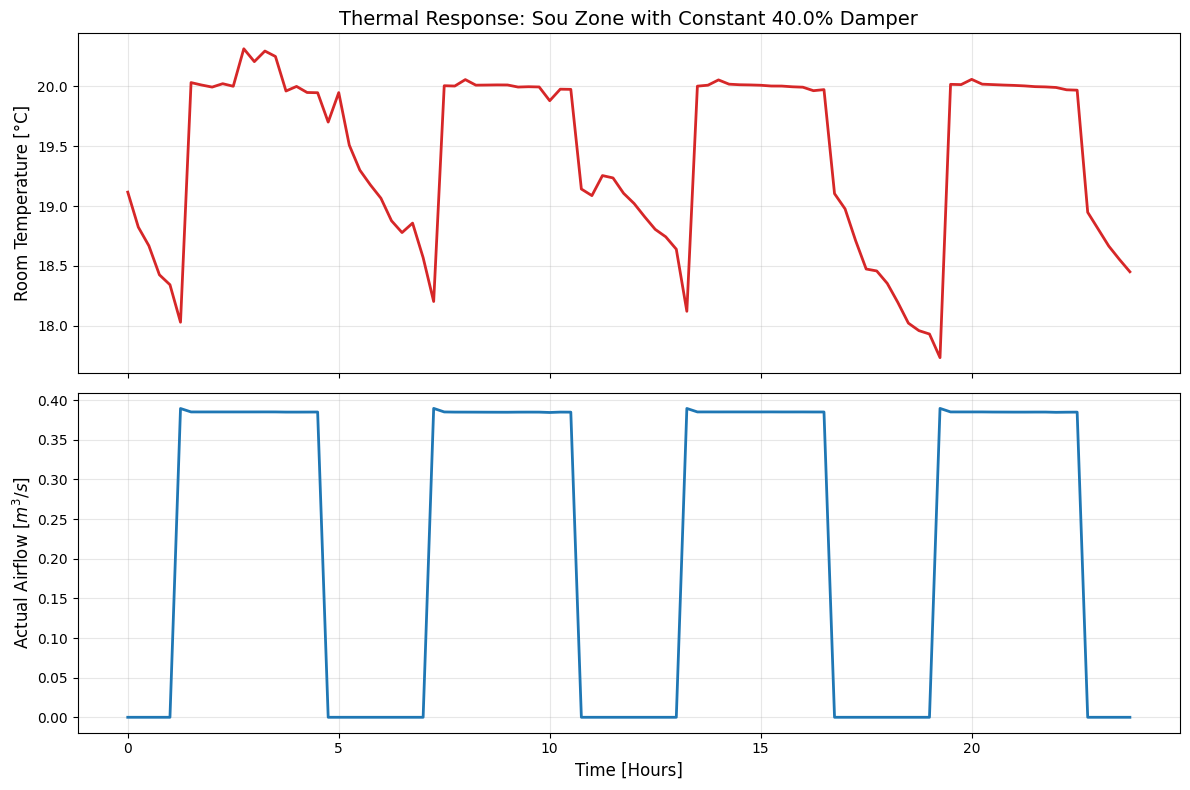

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
zone = "Sou"
damper_u = f"hvac_oveZonAct{zone}_yDam_u"
damper_act = f"hvac_oveZonAct{zone}_yDam_activate"
temp_sensor = f"hvac_reaZon{zone}_TZon_y"
flow_sensor = f"hvac_reaZon{zone}_V_flow_y"

constant_damper_pos = 0.4  # 40% open
step_size = 900            # 15-minute intervals (seconds)
sim_hours = 24
steps = int((sim_hours * 3600) / step_size)

results = []

print(f"Starting experiment: Locking {zone} damper at {constant_damper_pos*100}%")

for i in range(steps):
    # Construct the override
    # We tell BOPTEST: "Ignore the local PID, use this value instead."
    u = {
        damper_u: constant_damper_pos,
        damper_act: 1
    }
    
    # Advance simulation
    resp = requests.post(f"{url}/advance/{testid}", json=u).json()
    data = resp['payload']
    
    # Store relevant data
    results.append({
        'time_hours': i * (step_size / 3600),
        'temp_c': data[temp_sensor] - 273.15,  # K to C
        'actual_flow': data[flow_sensor],      # m3/s
        'fan_power': data['hvac_reaAhu_PFanSup_y'] # Bonus: See fan impact
    })

# --- ANALYSIS & PLOTTING ---
df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature Plot
ax1.plot(df['time_hours'], df['temp_c'], color='tab:red', linewidth=2)
ax1.set_ylabel('Room Temperature [°C]', fontsize=12)
ax1.set_title(f'Thermal Response: {zone} Zone with Constant {constant_damper_pos*100}% Damper', fontsize=14)
ax1.grid(True, alpha=0.3)

# Flow Plot
ax2.plot(df['time_hours'], df['actual_flow'], color='tab:blue', linewidth=2)
ax2.set_ylabel('Actual Airflow [$m^3/s$]', fontsize=12)
ax2.set_xlabel('Time [Hours]', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()